In [1]:
import sys
sys.path.append('../../utils/')

In [2]:
from Bias_Variance_Estimator import estimate_bias_variance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
def true_function(x):
    return torch.sin(2 * torch.pi * x)

def generate_dataset(n_samples=50, noise_std=0.1):
    x = torch.rand(n_samples, 1)
    y = true_function(x) + torch.randn_like(x) * noise_std
    return x, y

In [6]:
def plot_dataset(x_train, y_train, true_func=true_function, n_points=200):
    # Plot true function
    x_true = torch.linspace(0, 1, n_points).unsqueeze(1)
    y_true = true_func(x_true)

    plt.figure(figsize=(6, 4))
    plt.plot(x_true.numpy(), y_true.numpy(), label='True Function', color='black')
    plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Noisy Samples', alpha=0.7)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Noisy Dataset vs. True Function')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
X, y = generate_dataset(n_samples=50, noise_std=0.1)

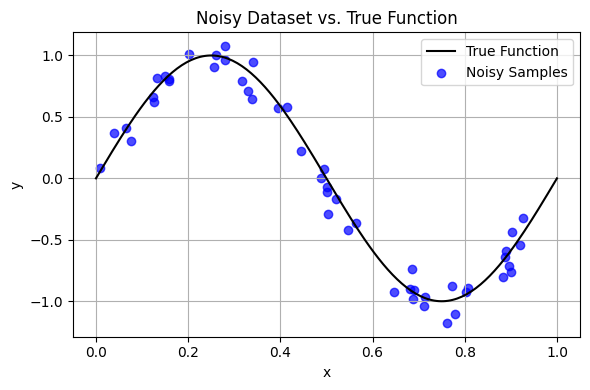

In [8]:
plot_dataset(X,y,true_function)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X.numpy(),y.numpy(),test_size = 0.25,random_state=42)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
## Converting to pytorch tensors
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train,dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test,dtype = torch.float32).view(-1,1)

In [12]:
## Creating dataloaders
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

In [13]:
def train_model(model,train_loader,epochs=20,lr=0.001):
    loss = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            l = loss(outputs,y_batch)
            l.backward()
            optimizer.step()
            running_loss+=l.item()*X_batch.size(0) ## stores the entire loss during an epoch

        cur_epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch {epoch+1}, Loss: {cur_epoch_loss:.4f}")

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate_model(model, test_loader):
    model.eval()
    mse_loss = nn.L1Loss()
    total_loss = 0.0
    all_preds=[]
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            loss = mse_loss(preds, y_batch)
            all_preds.append(preds)
            all_targets.append(y_batch)
            total_loss += loss.item() * X_batch.size(0)
    all_preds = torch.cat(all_preds).squeeze().numpy()
    all_targets = torch.cat(all_targets).squeeze().numpy()

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Test MSE: {total_loss / len(test_loader.dataset):.4f}")

In [15]:
class PolynomialRegression(nn.Module):
    def __init__(self,degree:int):
        super(PolynomialRegression,self).__init__()
        self.degree = degree
        self.linear = nn.Linear(degree+1,1)
    def forward(self, x):
        # x: shape [batch_size, 1]
        # Create polynomial features: [x^0, x^1, ..., x^degree]
        poly_features = torch.cat([x ** i for i in range(self.degree + 1)], dim=1)
        return self.linear(poly_features)

In [16]:
input_dim = X_train.shape[1]
model = PolynomialRegression(degree=3)
train_model(model, train_loader, epochs=20)

Epoch 1, Loss: 1.2141
Epoch 2, Loss: 1.2117
Epoch 3, Loss: 1.2092
Epoch 4, Loss: 1.2068
Epoch 5, Loss: 1.2044
Epoch 6, Loss: 1.2020
Epoch 7, Loss: 1.1996
Epoch 8, Loss: 1.1972
Epoch 9, Loss: 1.1948
Epoch 10, Loss: 1.1924
Epoch 11, Loss: 1.1899
Epoch 12, Loss: 1.1875
Epoch 13, Loss: 1.1851
Epoch 14, Loss: 1.1827
Epoch 15, Loss: 1.1803
Epoch 16, Loss: 1.1779
Epoch 17, Loss: 1.1755
Epoch 18, Loss: 1.1731
Epoch 19, Loss: 1.1707
Epoch 20, Loss: 1.1682


In [17]:
evaluate_model(model, test_loader)

MSE:  1.3527
RMSE: 1.1631
MAE:  1.1017
R²:   -1.3177
Test MSE: 1.1017


In [18]:
estimate_bias_variance(
    model_class=PolynomialRegression,# or any nn.Module class
    loss_fn=nn.L1Loss(),
    model_kwargs={'degree': 5},
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    num_models=30,
    epochs=20,
    
)

Training on first resample
epoch 0 loss 0.6859220266342163
epoch 1 loss 0.6848694086074829
epoch 2 loss 0.6838167905807495
epoch 3 loss 0.6827641725540161
epoch 4 loss 0.6817115545272827
epoch 5 loss 0.6806589365005493
epoch 6 loss 0.6796063184738159
epoch 7 loss 0.6785536408424377
epoch 8 loss 0.6775009632110596
epoch 9 loss 0.676448404788971
epoch 10 loss 0.6753957271575928
epoch 11 loss 0.6743431091308594
epoch 12 loss 0.673290491104126
epoch 13 loss 0.6722455620765686
epoch 14 loss 0.6714199185371399
epoch 15 loss 0.6705418229103088
epoch 16 loss 0.6696287989616394
epoch 17 loss 0.6686909794807434
epoch 18 loss 0.6677342057228088
epoch 19 loss 0.6667627096176147
Training on first resample
epoch 0 loss 0.6851544380187988
epoch 1 loss 0.6840773224830627
epoch 2 loss 0.683000385761261
epoch 3 loss 0.6819232702255249
epoch 4 loss 0.6808462738990784
epoch 5 loss 0.6797692775726318
epoch 6 loss 0.6786922812461853
epoch 7 loss 0.6776151657104492
epoch 8 loss 0.6765381693840027
epoch 9 los

E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:134: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  all_preds_tensor = torch.tensor(all_preds,dtype = torch.float32)
